# SemEval-2026 Task 12: Semantic Similarity Analysis

This notebook analyzes the semantic similarity between the `target_event` and various options in the dataset. It also compares the similarity of the `golden_answer` options with other options.

In [42]:
import pandas as pd
import json
import numpy as np
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cosine
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set_theme(style="whitegrid")

In [43]:
# Load data
data_path = '../../semeval2026-task12-dataset/test_data/questions.jsonl'
questions = []
with open(data_path, 'r') as f:
    for line in f:
        if line.strip():
            questions.append(json.loads(line))

df = pd.DataFrame(questions)
print(f"Loaded {len(df)} questions.")
df.head()

Loaded 612 questions.


,topic_id,id,target_event,option_A,option_B,option_C,option_D
0,37,q-2420,"The Crew Dragon, carried by a Falcon 9 rocket,...",SpaceX launched the Falcon 9 rocket carrying t...,SpaceX delayed its first crewed launch to the ...,President Trump and Vice President Pence atten...,NASA assigned Bob Behnken and Doug Hurley to l...
1,60,q-2421,Former Syrian President Bashar al-Assad flees ...,Rebel groups seize control of Damascus after l...,Rebel forces captured Hama.,The Syrian Democratic Forces entered Mayadin C...,Rebels take control of Aleppo city on November...
2,52,q-2422,Deputy Foreign Minister Ali Bagheri Kani was a...,Search-and-rescue operations for the crash wer...,"Iranian President Ebrahim Raisi, Foreign Minis...",Supreme Leader Ayatollah Ali Khamenei declared...,"Rescue and search teams, including military tr..."
3,60,q-2423,Former Syrian President Bashar al-Assad flees ...,"Rebels take control of Daraa, the birthplace o...",Rebel groups seize control of Damascus after l...,Rebels take control of Aleppo city on November...,The Syrian Democratic Forces entered Mayadin C...
4,58,q-2424,Jordan intercepted missiles and drones enterin...,"The U.S. military, including two American dest...",None of the others are correct causes.,Israeli police killed the two attackers in Jaffa.,A large-scale cyberattack accompanied the IRGC...


## Generate Embeddings

We use the `all-MiniLM-L6-v2` model for efficiency and good semantic representation.

In [44]:
model = SentenceTransformer('all-MiniLM-L6-v2')

def get_embeddings(texts):
    return model.encode(texts)

print("Generating embeddings for target events...")
df['target_event_emb'] = list(get_embeddings(df['target_event'].tolist()))

for opt in ['A', 'B', 'C', 'D']:
    print(f"Generating embeddings for option_{opt}...")
    df[f'option_{opt}_emb'] = list(get_embeddings(df[f'option_{opt}'].tolist()))

Generating embeddings for target events...
Generating embeddings for option_A...
Generating embeddings for option_B...
Generating embeddings for option_C...
Generating embeddings for option_D...


## Calculate Cosine Similarity

In [45]:
def calculate_similarity(row, option_col):
    emb1 = row['target_event_emb']
    emb2 = row[f'option_{option_col}_emb']
    # cosine distance is 1 - similarity
    return 1 - cosine(emb1, emb2)

for opt in ['A', 'B', 'C', 'D']:
    df[f'sim_{opt}'] = df.apply(lambda row: calculate_similarity(row, opt), axis=1)

## Golden Answer Analysis

Analyze the difference in similarity between golden answers and non-golden options.

In [46]:
# Let's load golden answers from the reference data
reference_path = '../../semeval2026-task12-dataset/reference.jsonl'
golden_map = {}
with open(reference_path, 'r') as f:
    for line in f:
        if line.strip():
            ref = json.loads(line)
            golden_map[ref['id']] = ref['answer']

df['golden_answer'] = df['id'].map(golden_map)
df = df.dropna(subset=['golden_answer'])

print(f"After mapping golden answers, we have {len(df)} questions.")

After mapping golden answers, we have 612 questions.


In [47]:
irrelevant_pattern = "None of the others are correct causes"
    
def is_irrelevant_question(row):
    golden_labels = [s.strip() for s in str(row['golden_answer']).split(',')]
    for label in golden_labels:
        if label in ['A', 'B', 'C', 'D']:
            option_text = row[f'option_{label}']
            if irrelevant_pattern in option_text:
                return True
    return False

df= df[~df.apply(is_irrelevant_question, axis=1)].copy()
print(f"After filtering no-answers questions, we have {len(df)} questions.")

After filtering no-answers questions, we have 386 questions.


In [48]:
def get_golden_sims(row):
    golden_labels = [s.strip() for s in str(row['golden_answer']).split(',')]
    sims = []
    for label in golden_labels:
        if label in ['A', 'B', 'C', 'D']:
            if irrelevant_pattern in str(row[f'option_{label}']):
                continue
            sims.append(row[f'sim_{label}'])
    return sims

def get_non_golden_sims(row):
    golden_labels = [s.strip() for s in str(row['golden_answer']).split(',')]
    sims = []
    for label in ['A', 'B', 'C', 'D']:
        if label not in golden_labels:
            if irrelevant_pattern in str(row[f'option_{label}']):
                continue
            sims.append(row[f'sim_{label}'])
    return sims

df['golden_sims'] = df.apply(get_golden_sims, axis=1)
df['non_golden_sims'] = df.apply(get_non_golden_sims, axis=1)

# Flatten the lists for distribution analysis
all_golden_sims = [sim for sims in df['golden_sims'] for sim in sims]
all_non_golden_sims = [sim for sims in df['non_golden_sims'] for sim in sims]

stats_df = pd.DataFrame({
    'Similarity': all_golden_sims + all_non_golden_sims,
    'Type': ['Golden'] * len(all_golden_sims) + ['Non-Golden'] * len(all_non_golden_sims)
})

print("Mean Golden Similarity:", np.mean(all_golden_sims))
print("Mean Non-Golden Similarity:", np.mean(all_non_golden_sims))

Mean Golden Similarity: 0.3731769820054372
Mean Non-Golden Similarity: 0.2910252709792355


## Ranking Performance Analysis

We evaluate how well cosine similarity performs as a ranking metric for the answers.

In [49]:
def calculate_ranking_metrics(df):
    mrr_list = []
    p1_count = 0
    
    for _, row in df.iterrows():
        # Get similarities for all options
        sims = {
            'A': row['sim_A'],
            'B': row['sim_B'],
            'C': row['sim_C'],
            'D': row['sim_D']
        }
        
        # Sort options by similarity descending
        sorted_options = sorted(sims.items(), key=lambda x: x[1], reverse=True)
        ranked_labels = [opt for opt, sim in sorted_options]
        
        # Golden labels
        golden_labels = [s.strip() for s in str(row['golden_answer']).split(',')]
        
        # Precision@1: Is the top option in golden?
        if ranked_labels[0] in golden_labels:
            p1_count += 1
            
        # MRR: 1 / rank of the first golden answer found
        for i, label in enumerate(ranked_labels):
            if label in golden_labels:
                mrr_list.append(1.0 / (i + 1))
                break
                
    mrr = np.mean(mrr_list) if mrr_list else 0
    p1 = p1_count / len(df) if len(df) > 0 else 0
    
    return mrr, p1

mrr, p1 = calculate_ranking_metrics(df)
print(f"Mean Reciprocal Rank (MRR): {mrr:.4f}")
print(f"Precision@1: {p1:.4f}")

Mean Reciprocal Rank (MRR): 0.6844
Precision@1: 0.4534


## Visualization

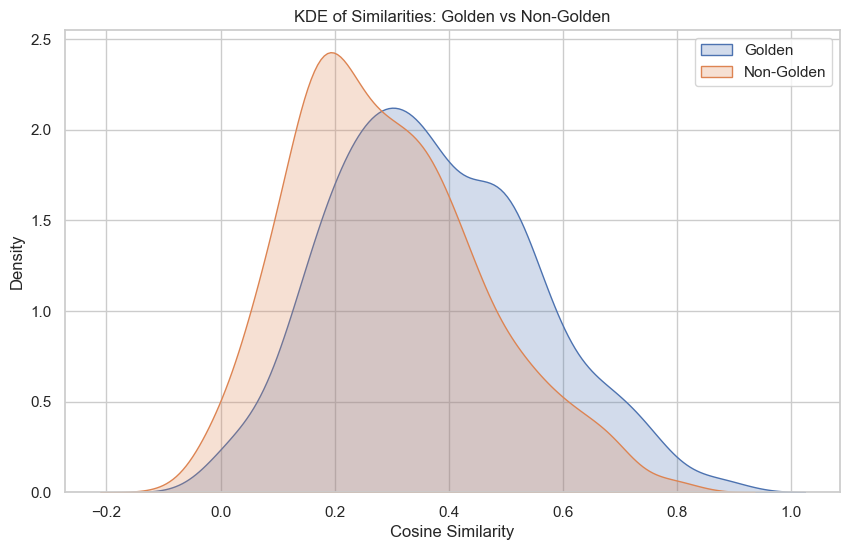

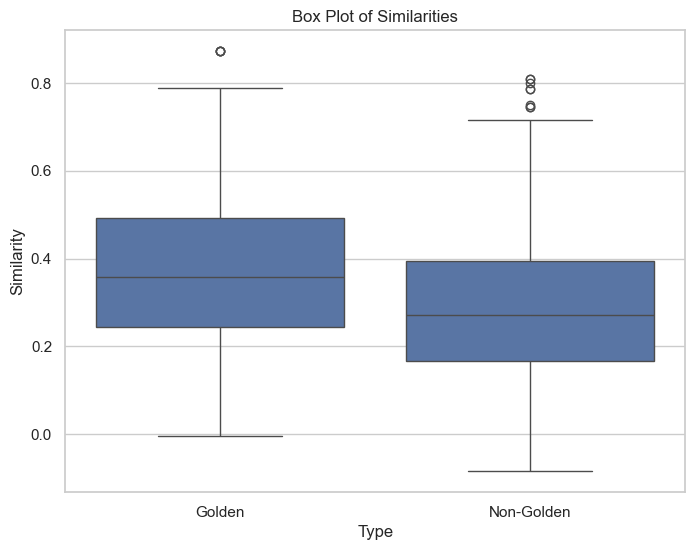

In [51]:
plt.figure(figsize=(10, 6))
sns.kdeplot(all_golden_sims, label='Golden', fill=True)
sns.kdeplot(all_non_golden_sims, label='Non-Golden', fill=True)
plt.title('KDE of Similarities: Golden vs Non-Golden')
plt.xlabel('Cosine Similarity')
plt.legend()
plt.show()

stats_df = pd.DataFrame({
    'Similarity': all_golden_sims + all_non_golden_sims,
    'Type': ['Golden'] * len(all_golden_sims) + ['Non-Golden'] * len(all_non_golden_sims)
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=stats_df, x='Type', y='Similarity')
plt.title('Box Plot of Similarities')
plt.show()